This notebook reproduces the **MATLAB deep hedging experiment**

Outputs reproduced:
1. Hedge cost comparison table
2. Histogram of hedge costs
3. RL hedge vs Black‑Scholes delta plot


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm


## Black–Scholes pricing

Kontrollera denna. Något är galet. Vi använde moneyness och detta fungeart ej då

In [2]:

def bs_call_price_delta_safe(S, K, tau, r, sigma):
    if tau <= 1e-12:
        #print("help me")
        payoff = max(S - K, 0)
        delta  = 1.0 if S > K else (0.5 if S == K else 0.0)
        return float(payoff), float(delta)
    d1    = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2    = d1 - sigma * np.sqrt(tau)
    price = S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    delta = norm.cdf(d1)
    return float(price), float(delta)


## MATLAB-style hedging environment

In [3]:

class MatlabQHedgingEnv:

    def __init__(self,strike,maturity,spot,vol,mu,r,dT,c,kappa,init_pos,seed=0):
        
        self.K=strike
        self.T=maturity
        self.S0=spot
        self.sigma=vol
        self.mu=mu
        self.r=r
        self.dt=dT
        
        self.c=c
        self.kappa=kappa
        
        self.init_pos=init_pos
        
        self.steps=int(round(self.T/self.dt))
        
        self.rng=np.random.default_rng(seed)
        self.reset()
        
    def reset(self):
        
        self.S=self.S0/self.K # TODO: Check moneyness
        self.tau=self.T
        self.pos=self.init_pos
        self.ti:int = 0

        
        return self._obs()
    
    def _obs(self):
        
        return np.array([
            self.S/self.K,
            self.tau,
            self.pos
        ],dtype=np.float32)
    # Inkonsekvent med att vi använder moneyness i observationen. Kanske borde använda det i option price också? Eller så ändrar vi observationen till att inte använda moneyness.
    def _option_price(self,S,tau):
        p,_=bs_call_price_delta_safe(S,self.K,tau,self.r,self.sigma)
        return p
    
    def _simulate(self):
        
        z=self.rng.standard_normal()
        
        return self.S*((1+self.mu*self.dt)+z*self.sigma*np.sqrt(self.dt))
    
    def step(self,target_pos):
        
        pos_prev=self.pos
        S_prev=self.S
        tau_prev=self.tau
        self.ti+=1
        
        pos_next=float(np.clip(target_pos,0,1))
        
        S_next=self._simulate() 
        tau_next=max(0,tau_prev-self.dt) # TODO: Should never be negative, but we should check if it can be zero and if that causes any issues in option pricing.
        
        C_prev=self._option_price(S_prev,tau_prev)
        C_next=self._option_price(S_next,tau_next)
        
        stepReward=(
            (S_next-S_prev)*pos_prev
            -abs(pos_next-pos_prev)*S_next*self.kappa
            -C_next
            +C_prev
        )
        
        done = self.ti >= self.steps # TODO: Check if step is "-1"
        #done=tau_next<1e-12
        
        if done:
            stepReward-=pos_next*S_next*self.kappa 
        
        #reward=stepReward-self.c*stepReward**2 #: TODO: Check if good or not
        reward = stepReward 
        self.S=S_next
        self.tau=tau_next
        self.pos=pos_next
        
        return self._obs(),reward,done,{}


## Discretization

Ta bort. Kan göra mycket smartare

In [4]:

def make_discretizer(T,n_time,n_moneyness,n_pos,m_min,m_max):

    m_edges=np.linspace(m_min,m_max,n_moneyness)
    pos_grid=np.linspace(0,1,n_pos)

    def discretize(obs):

        m,tau,pos=obs
        
        t_frac=1-tau/T
        
        t_idx=int(np.clip(np.floor(t_frac*n_time),0,n_time-1))
        
        m_idx=int(np.clip(np.digitize(m,m_edges)-1,0,len(m_edges)-2))
        
        p_idx=int(np.argmin(np.abs(pos_grid-pos)))
        
        return (t_idx,m_idx,p_idx)
    
    return discretize,m_edges,pos_grid


## Q‑learning

In [5]:

def q_learning(env, actions, discretize, nT, nM, nP, episodes, alpha, gamma, eps, eps_decay, eps_min):
    Q = np.zeros((nT, nM, nP, len(actions)))
    rewards = []

    rng = np.random.default_rng(8)

    for ep in range(episodes):
        obs = env.reset()
        s = discretize(obs) # TODO: Ingen discretize om man gör rätt...
        done = False
        ep_reward = 0.0

        while not done:
            if rng.random() < eps:
                a_idx = rng.integers(len(actions))
            else:
                a_idx = np.argmax(Q[s])

            a = actions[a_idx]
            obs2, r, done, _ = env.step(a)
            s2 = discretize(obs2)

            # TODO: Kolla mot Bellman. Stycket är skakigt
            best_next = 0.0 if done else np.max(Q[s2])
            td = r + gamma * best_next - Q[s + (a_idx,)] # TODO: r är dumt. Låt det vara reward istället
            Q[s + (a_idx,)] += alpha * td

            ep_reward += r
            s = s2

        eps = max(eps_min, eps * eps_decay)
        rewards.append(ep_reward)

    return Q, rewards


## MATLAB computeCosts equivalent

In [6]:

def simulate_paths(S0,mu,sigma,dT,nSteps,nTrials):

    paths=np.zeros((nSteps+1,nTrials))
    paths[0]=S0
    
    rng=np.random.default_rng(0)
    
    for t in range(1,nSteps+1):
        
        z=rng.standard_normal(nTrials)
        
        paths[t]=paths[t-1]*((1+mu*dT)+z*sigma*np.sqrt(dT))
    
    times=np.arange(nSteps+1)*dT
    
    return paths,times


In [7]:

def compute_costs(policy, nTrials, nSteps, S0, K, T, r, sigma, init_pos, dT, mu, kappa):

    paths, times = simulate_paths(S0, mu, sigma, dT, nSteps, nTrials)

    costs = np.zeros(nTrials)

    pos_prev = np.ones(nTrials) * init_pos
    pos_next = policy(paths[0] / K, T * np.ones(nTrials), pos_prev)

    for t in range(1, nSteps + 1):

        S_now = paths[t]
        S_prev = paths[t - 1]

        tau_now = np.maximum(0.0, T - times[t]) * np.ones(nTrials)
        tau_prev = np.maximum(0.0, T - times[t - 1]) * np.ones(nTrials)

        C_now = np.array([
            bs_call_price_delta_safe(s, K, tau, r, sigma)[0]
            for s, tau in zip(S_now, tau_now)
        ])

        C_prev = np.array([
            bs_call_price_delta_safe(s, K, tau, r, sigma)[0]
            for s, tau in zip(S_prev, tau_prev)
        ])

        step = (
            (S_now - S_prev) * pos_prev
            - np.abs(pos_next - pos_prev) * S_now * kappa
            - C_now
            + C_prev
        )

        if t == nSteps:
            step -= pos_next * S_now * kappa

        costs += step

        if t < nSteps:
            pos_prev = pos_next
            pos_next = policy(
                paths[t] / K,
                np.maximum(0.0, T - times[t]) * np.ones(nTrials),
                pos_prev
            )

    return costs


## Experiment parameters (same as MATLAB)

In [8]:

Strike=100
Maturity=1

SpotPrice=100
ExpVol=0.2
ExpReturn=0.05

rfRate=0
dT=1/250

nSteps=int(round(Maturity/dT))

c=1.1
kappa=0.01
InitPosition=0

n_m_bins = 21
n_pos_bins = 31
episodes = 1000

alpha = 0.01
gamma = 0.9995

eps = 0.4
eps_decay = 0.99998
eps_min = 0.02


In [9]:

env=MatlabQHedgingEnv(
    Strike,Maturity,SpotPrice,ExpVol,ExpReturn,rfRate,dT,c,kappa,InitPosition
)


In [10]:

n_time_bins=nSteps
n_m_bins=41
n_pos_bins=11

discretize,m_edges,pos_grid=make_discretizer(
    Maturity,n_time_bins,n_m_bins,n_pos_bins,0.8,1.2
)

actions=pos_grid.copy()


In [11]:

Q, rewards = q_learning(
    env,actions,discretize,
    n_time_bins,len(m_edges)-1,len(pos_grid),
    episodes=episodes,
    alpha=alpha,
    gamma=gamma,
    eps=eps,
    eps_decay=eps_decay,
    eps_min=eps_min
)


## Define policies

In [12]:

def policy_RL(mR,TTM,Pos):

    out=np.zeros_like(mR)
    
    for i in range(len(mR)):
        
        obs=np.array([mR[i],TTM[i],Pos[i]])
        s=discretize(obs)
        
        a=np.argmax(Q[s])
        
        out[i]=actions[a]
    
    return out


In [ ]:

def policy_BSM(mR,TTM,Pos,K,rfRate,ExpVol):

    out=np.zeros_like(mR)
    
    for i in range(len(mR)):
        
        _,delta=bs_call_price_delta_safe(mR[i]*K,1,max(TTM[i],1e-12),rfRate,ExpVol) # Dumt, fungerar ej
        
        out[i]=delta
    
    return out


## Evaluate hedge costs

In [ ]:
Costs_BSM=compute_costs(
    lambda mR, TTM, pos: policy_BSM(mR, TTM, pos, K, rfRate, ExpVol),1000,nSteps,
    SpotPrice,Strike,Maturity,rfRate,
    ExpVol,InitPosition,dT,ExpReturn,kappa
)

Costs_RL=compute_costs(
    policy_RL,1000,nSteps,
    SpotPrice,Strike,Maturity,rfRate,
    ExpVol,InitPosition,dT,ExpReturn,kappa
)

OptionPrice,_=bs_call_price_delta_safe(SpotPrice,Strike,Maturity,rfRate,ExpVol)

table=pd.DataFrame(
    {
        "BSM":100*np.array([-np.mean(Costs_BSM),np.std(Costs_BSM)])/OptionPrice,
        "RL":100*np.array([-np.mean(Costs_RL),np.std(Costs_RL)])/OptionPrice
    },
    index=["Average Hedge Cost (% of Option Price)","STD Hedge Cost (% of Option Price)"]
)

table


,BSM,RL
Average Hedge Cost (% of Option Price),77.654105,40.638979
STD Hedge Cost (% of Option Price),25.952303,195.120955


## Histogram comparison

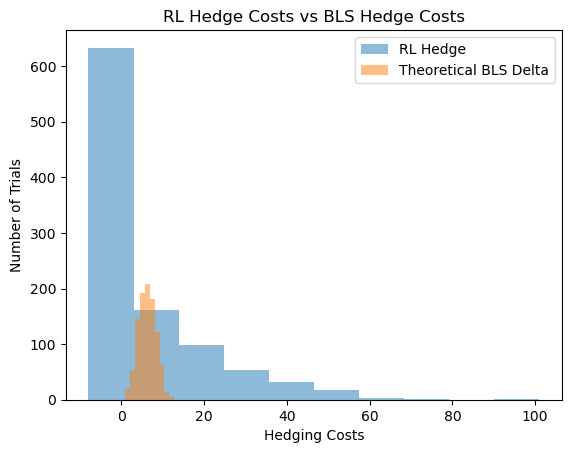

In [15]:

plt.figure()

plt.hist(-Costs_RL,bins=10,alpha=0.5,label="RL Hedge")
plt.hist(-Costs_BSM,bins=10,alpha=0.5,label="Theoretical BLS Delta")

plt.xlabel("Hedging Costs")
plt.ylabel("Number of Trials")

plt.title("RL Hedge Costs vs BLS Hedge Costs")

plt.legend()

plt.show()


## RL hedge vs Black–Scholes delta

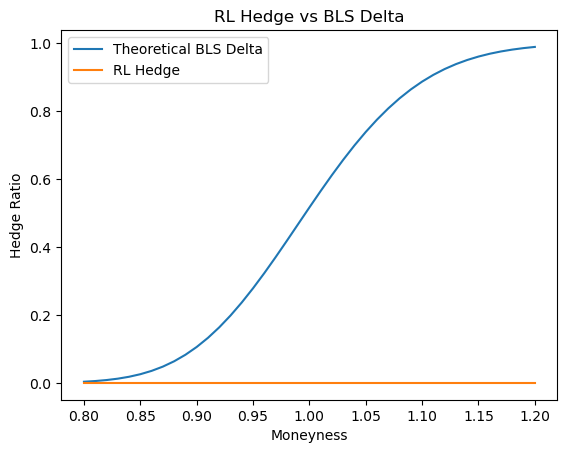

In [16]:

mRange=np.arange(.8,1.2001,.01)

t_plot=2/12

bsm=[]
rl=[]

for m in mRange:
    
    _,d=bs_call_price_delta_safe(m,1,t_plot,rfRate,ExpVol)
    
    bsm.append(d)
    
    rl.append(policy_RL(
        np.array([m]),
        np.array([t_plot]),
        np.array([d])
    )[0])

plt.figure()

plt.plot(mRange,bsm,label="Theoretical BLS Delta")
plt.plot(mRange,rl,label="RL Hedge")

plt.xlabel("Moneyness")
plt.ylabel("Hedge Ratio")

plt.title("RL Hedge vs BLS Delta")

plt.legend()

plt.show()


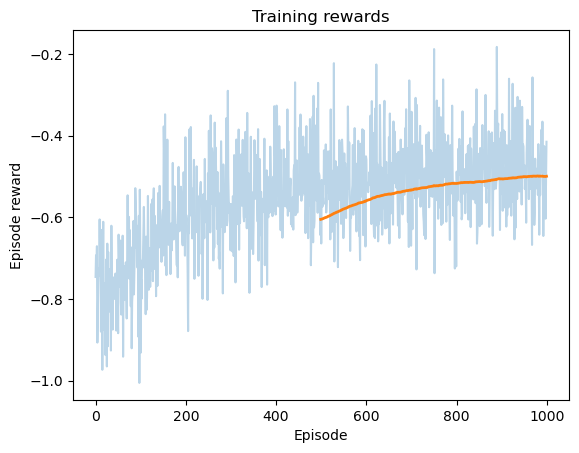

In [17]:
plt.plot(rewards, alpha=0.3)
window = 500
ma = np.convolve(rewards, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(rewards)), ma, linewidth=2)
plt.title("Training rewards")
plt.xlabel("Episode")
plt.ylabel("Episode reward")
plt.show()

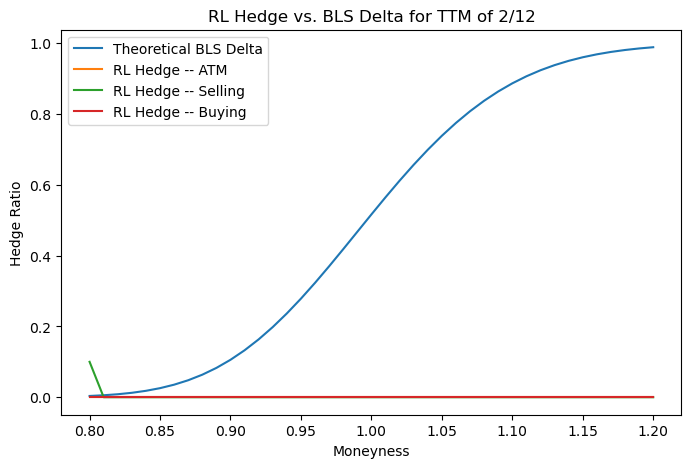

In [18]:
mRange = np.arange(0.8, 1.2001, 0.01)
t_plot = 2/12

bsm_line = []
rl_atm = []
rl_selling = []
rl_buying = []

for m in mRange:
    _, d_atm = bs_call_price_delta_safe(m, 1.0, t_plot, rfRate, ExpVol)
    _, d_sell = bs_call_price_delta_safe(m + 0.1, 1.0, t_plot, rfRate, ExpVol)
    _, d_buy  = bs_call_price_delta_safe(m - 0.1, 1.0, t_plot, rfRate, ExpVol)

    bsm_line.append(d_atm)

    rl_atm.append(policy_RL(
        np.array([m]),
        np.array([t_plot]),
        np.array([d_atm])
    )[0])

    rl_selling.append(policy_RL(
        np.array([m]),
        np.array([t_plot]),
        np.array([d_sell])
    )[0])

    rl_buying.append(policy_RL(
        np.array([m]),
        np.array([t_plot]),
        np.array([d_buy])
    )[0])

plt.figure(figsize=(8,5))
plt.plot(mRange, bsm_line, label="Theoretical BLS Delta")
plt.plot(mRange, rl_atm, label="RL Hedge -- ATM")
plt.plot(mRange, rl_selling, label="RL Hedge -- Selling")
plt.plot(mRange, rl_buying, label="RL Hedge -- Buying")
plt.xlabel("Moneyness")
plt.ylabel("Hedge Ratio")
plt.title("RL Hedge vs. BLS Delta for TTM of 2/12")
plt.legend()
plt.show()